In [1]:
# SVM
import numpy as np
from sklearn import svm

X = np.array([[1, 2], [2, 3], [3, 3], [5, 5], [6, 6], [7, 8]])
y = np.array([0, 0, 0, 1, 1, 1])
model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)
print("Prediction for [4,4]:", model.predict([[4, 4]]))
print("Prediction for [2,2]:", model.predict([[2, 2]]))

Prediction for [4,4]: [1]
Prediction for [2,2]: [0]


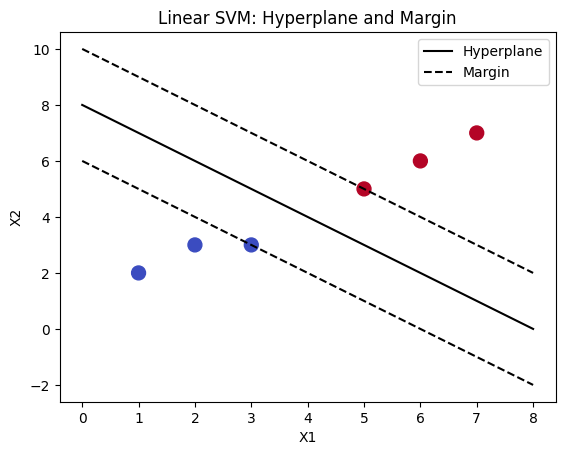

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

X = np.array([[1, 2], [2, 3], [3, 3], [5, 5], [6, 6], [7, 7]]) # Simple linearly separable data
y = np.array([0, 0, 0, 1, 1, 1])

model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, cmap='coolwarm') #x-coordinate & y of each point # 0 and 1 diff colour(c=y) ,s: size of dot

# Get weights and bias # Hyperplane: w0*x + w1*y + b = 0
w = model.coef_[0]
b = model.intercept_[0]

x_plot = np.linspace(0, 8, 100) # x values for plotting
y_hyperplane = -(w[0]*x_plot + b)/w[1] #finding y value solving hyperplane equation

# Margins: w0*x + w1*y + b = ±1
y_margin_positive = -(w[0]*x_plot + b - 1)/w[1]
y_margin_negative = -(w[0]*x_plot + b + 1)/w[1]

plt.plot(x_plot, y_hyperplane, 'k-', label='Hyperplane')
plt.plot(x_plot, y_margin_positive, 'k--', label='Margin')
plt.plot(x_plot, y_margin_negative, 'k--')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Linear SVM: Hyperplane and Margin')
plt.show()

Training data:
 [[2 3]
 [7 7]
 [1 2]
 [6 6]]
Training labels:
 [0 1 0 1]
Testing data:
 [[5 5]
 [3 3]]
Testing labels:
 [1 0]

Accuracy on test data: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



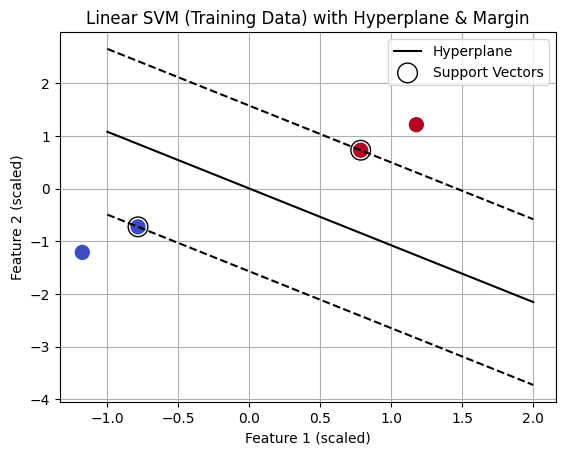

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
X = np.array([
    [1, 2], [2, 3], [3, 3],  # Class 0
    [5, 5], [6, 6], [7, 7]   # Class 1
])
y = np.array([0, 0, 0, 1, 1, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)
print("Training data:\n", X_train)
print("Training labels:\n", y_train)
print("Testing data:\n", X_test)
print("Testing labels:\n", y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='linear', C=1.0, probability=True)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("\nAccuracy on test data:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

w = model.coef_[0]
b = model.intercept_[0]

x_plot = np.linspace(-1, 2, 100)  
y_hyperplane = -(w[0]*x_plot + b)/w[1]
y_margin_pos = -(w[0]*x_plot + b - 1)/w[1]
y_margin_neg = -(w[0]*x_plot + b + 1)/w[1]

plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=y_train, s=100, cmap='coolwarm')
plt.plot(x_plot, y_hyperplane, 'k-', label='Hyperplane')
plt.plot(x_plot, y_margin_pos, 'k--')
plt.plot(x_plot, y_margin_neg, 'k--')
plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Linear SVM (Training Data) with Hyperplane & Margin')
plt.legend()
plt.grid(True)
plt.show()

Accuracy: 0.9777777777777777
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



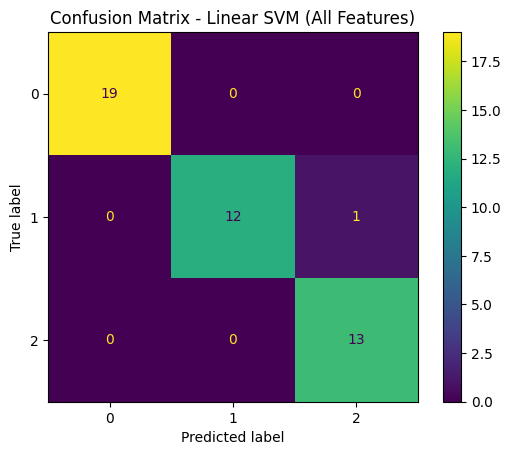

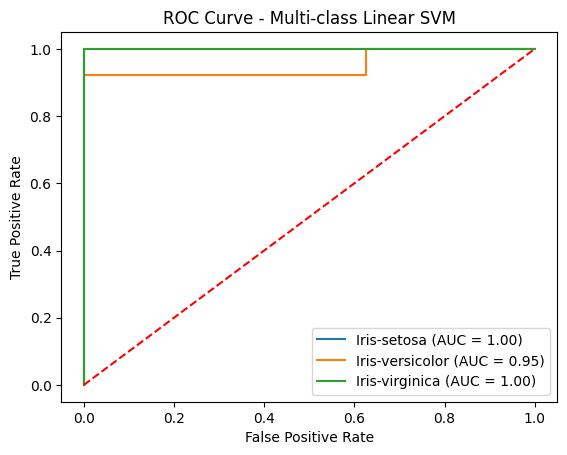

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/hp/Downloads/archive (9)/Iris.csv')

le = LabelEncoder() # Convert species to numeric labels
df['target'] = le.fit_transform(df['Species'])

# Features and target (all 4 features)
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_clf = SVC(kernel='linear', C=1, decision_function_shape='ovr')  # One-vs-Rest for multi-class
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix - Linear SVM (All Features)')
plt.show()

# ROC Curve for multi-class (One-vs-Rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = svm_clf.decision_function(X_test)

for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.2f})')

plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-class Linear SVM')
plt.legend()
plt.show()

Saved wine.csv successfully!
Test Accuracy: 0.981


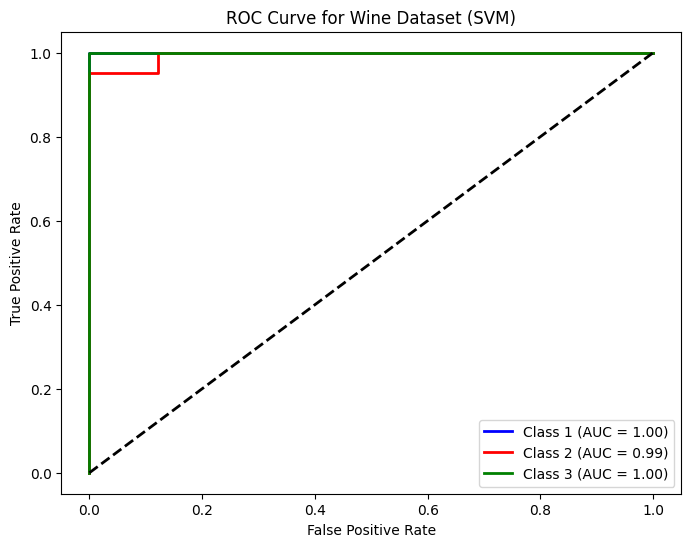

In [5]:
#TASK 8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.multiclass import OneVsRestClassifier

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
columns = ['Class','Alcohol','Malic_acid','Ash','Alcalinity_of_ash','Magnesium',
           'Total_phenols','Flavanoids','Nonflavanoid_phenols','Proanthocyanins',
           'Color_intensity','Hue','OD280/OD315_of_diluted_wines','Proline']

df = pd.read_csv(url, names=columns)
df.to_csv("wine.csv", index=False)
print("Saved wine.csv successfully!")

data = pd.read_csv("wine.csv")

X = data.drop('Class', axis=1)
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=42))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

#  ROC curve for multi-class
y_test_bin = label_binarize(y_test, classes=[1,2,3])
y_score = clf.decision_function(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#  Plot ROC curves
plt.figure(figsize=(8,6))
colors = ['blue','red','green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i+1} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Wine Dataset (SVM)')
plt.legend(loc='lower right')
plt.show()

In [6]:
#NON LINEAR
from sklearn.datasets import make_circles
from sklearn.svm import SVC

X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42) #The ratio of inner circle’s radius to outer circle’s radius
model = SVC(kernel='rbf', C=1.0, gamma='auto') #how tightly or loosely the model fits around each data point.
model.fit(X, y)
new_points = [[0, 0], [0.7, 0.7], [-0.6, -0.6]]
predictions = model.predict(new_points)
print("Predictions for new points:", predictions) 

Predictions for new points: [1 0 0]


In [7]:
#Polynoimal kernel (XOR pattern (classic non-linear example))
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,1,1,0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
poly_model = SVC(kernel='poly', degree=2, C=1.0)
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)
print("Polynomial Kernel Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

Polynomial Kernel Predictions: [0]
Accuracy: 0.0


In [8]:
#Rbf kernel(Circular data)
import numpy as np
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rbf_model = SVC(kernel='rbf', C=1.0, gamma='auto')
rbf_model.fit(X_train, y_train)
y_pred = rbf_model.predict(X_test)
print("RBF Kernel Predictions:", y_pred[:10], "...")  # first 10 predictions

RBF Kernel Predictions: [0 0 1 0 0 0 0 1 0 1] ...


In [9]:
#Sigmoid kernel(Random non linear pattern)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sigmoid_model = SVC(kernel='sigmoid', C=1.0, gamma='auto')
sigmoid_model.fit(X_train, y_train)
y_pred = sigmoid_model.predict(X_test)
print("Sigmoid Kernel Predictions:", y_pred[:10], "...")

Sigmoid Kernel Predictions: [0 0 1 0 0 0 0 1 0 1] ...


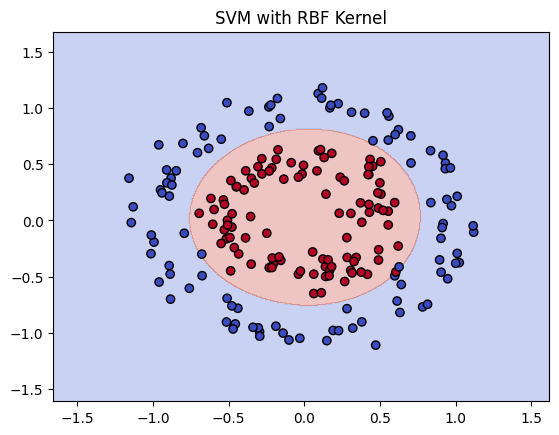

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)
rbf_model = SVC(kernel='rbf', C=1.0, gamma='auto')
rbf_model.fit(X, y)
# Create meshgrid for plotting
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 500),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 500))
Z = rbf_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) #.ravel() means “flatten” into a 1D array.

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM with RBF Kernel")
plt.show()

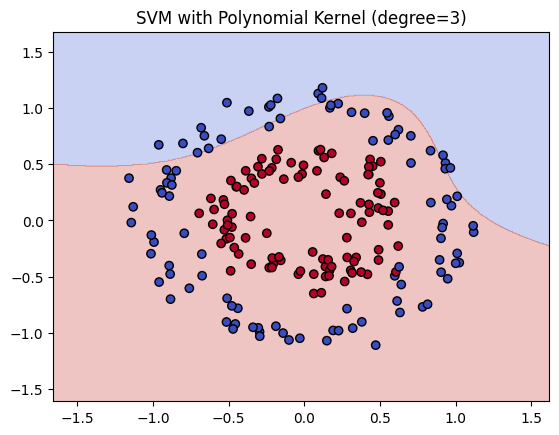

In [11]:
poly_model = SVC(kernel='poly', degree=3, C=1.0, gamma='auto')
poly_model.fit(X, y)

# Meshgrid for plotting
Z = poly_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM with Polynomial Kernel (degree=3)")
plt.show()

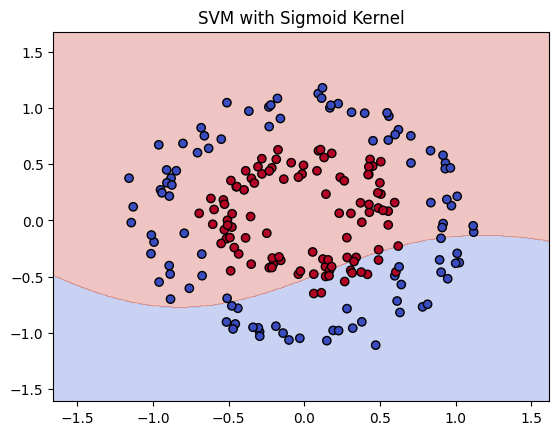

In [12]:
sigmoid_model = SVC(kernel='sigmoid', C=1.0, gamma='auto')
sigmoid_model.fit(X, y)

# Meshgrid for plotting
Z = sigmoid_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM with Sigmoid Kernel")
plt.show()

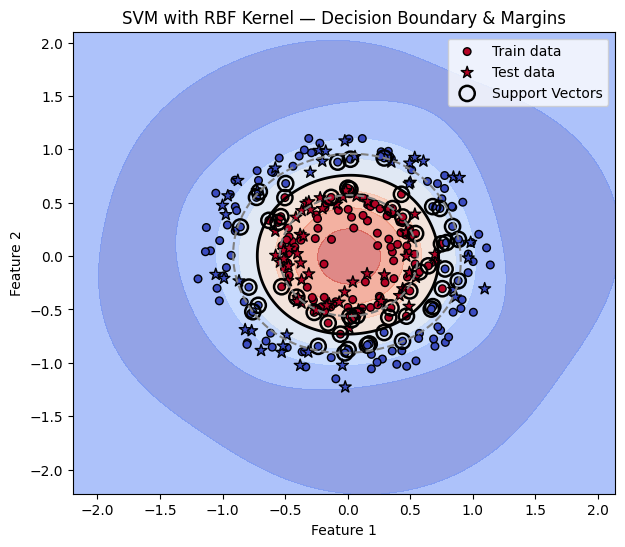

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='rbf', C=1, gamma=1)
clf.fit(X_train, y_train)

# Create a grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# Evaluate the decision function on the grid
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary, margins, and data points
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6) # Decision regions
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2) # Decision boundary (f(x)=0)
plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linestyles='--', linewidths=1.5) # Margins (f(x)=±1)

# Training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm,
            s=30, edgecolors='k', label='Train data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm,
            s=80, edgecolors='k', marker='*', label='Test data')

# Support vectors (circled)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black', linewidths=1.8, label='Support Vectors')

plt.title("SVM with RBF Kernel — Decision Boundary & Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

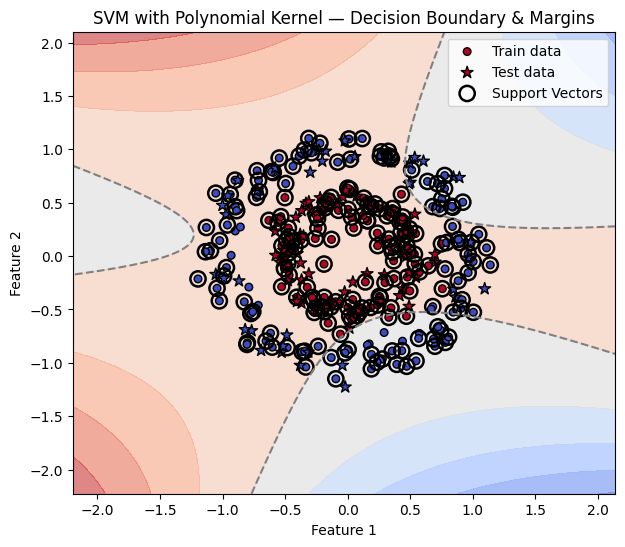

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='poly', degree=3, C=1, gamma='auto')
clf.fit(X_train, y_train)

# Create a grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# Evaluate the decision function on the grid
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary, margins, and data points
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6) # Decision regions
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2) # Decision boundary (f(x)=0)
plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linestyles='--', linewidths=1.5) # Margins (f(x)=±1)

# Training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm,
            s=30, edgecolors='k', label='Train data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm,
            s=80, edgecolors='k', marker='*', label='Test data')

# Support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black', linewidths=1.8, label='Support Vectors')
plt.title("SVM with Polynomial Kernel — Decision Boundary & Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

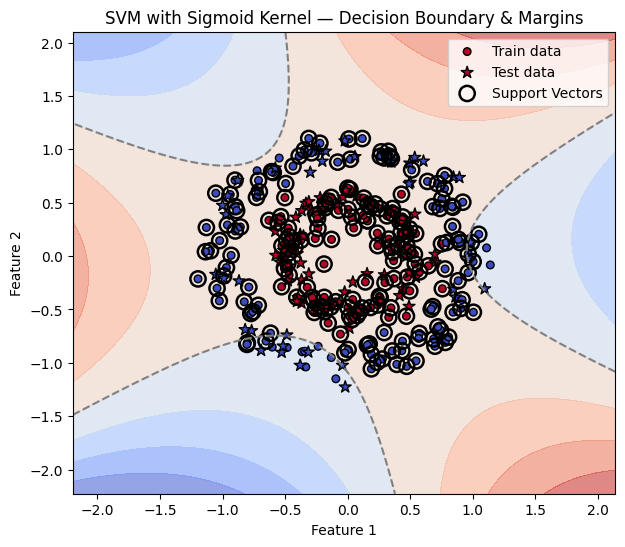

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='sigmoid', C=1, gamma=0.1, coef0=0)
clf.fit(X_train, y_train)

# Create a grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# Evaluate the decision function on the grid
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary, margins, and data points
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6) # Decision regions
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2) # Decision boundary (f(x)=0)
plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linestyles='--', linewidths=1.5) # Margins (f(x)=±1)

# Training and test points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm,
            s=30, edgecolors='k', label='Train data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm,
            s=80, edgecolors='k', marker='*', label='Test data')

# Support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black', linewidths=1.8, label='Support Vectors')
plt.title("SVM with Sigmoid Kernel — Decision Boundary & Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Accuracy: 0.7445887445887446

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       151
           1       0.64      0.59      0.61        80

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231


Confusion Matrix:
 [[125  26]
 [ 33  47]]


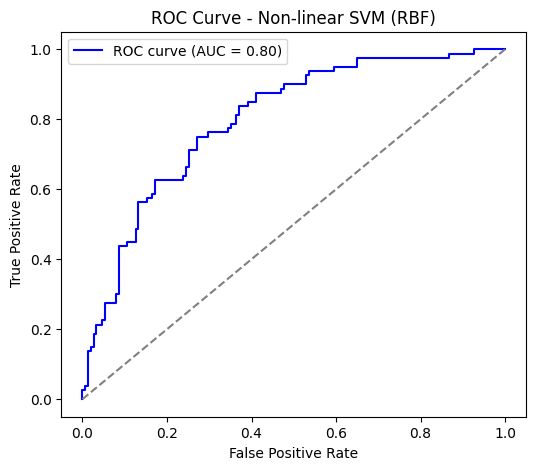

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI',
           'DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, names=columns)

X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Non-linear SVM (RBF)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [17]:
# NAVIE BAYES

In [18]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = [[5.1, 3.5, 1.4, 0.2],
     [4.9, 3.0, 1.4, 0.2],
     [6.2, 3.4, 5.4, 2.3],
     [5.9, 3.0, 5.1, 1.8]]
y = [0, 0, 1, 1]  # Class labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


GaussianNB Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [19]:
# Multinomial Naive Bayes 
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer

texts = ["I love programming", "Python is amazing", "I hate bugs", "Debugging is fun"]
labels = [1, 1, 0, 1]  # 1 = positive, 0 = negative

vectorizer = CountVectorizer()# Convert text to feature vectors
X = vectorizer.fit_transform(texts)
y = labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

MultinomialNB Accuracy: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [20]:
# Bernoulli Naive Bayes Example
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
X = np.array([[1,0,1,0],
              [0,1,1,0],
              [1,1,0,1],
              [0,0,1,1]])
y = np.array([1,0,1,0])  # Class labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

BernoulliNB Accuracy: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Predicated: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']
Accuracy: 1.0


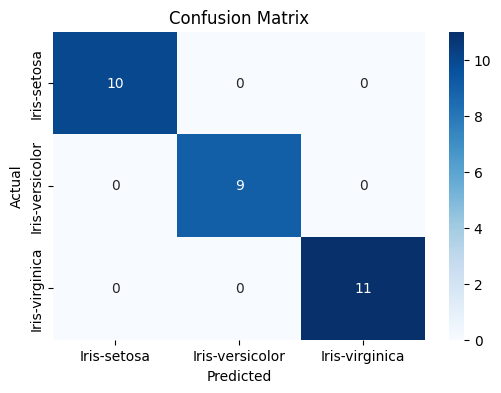

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/hp/Downloads/archive (9)/Iris.csv')
print(df.head())
X = df.drop('Species', axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("Predicated:",y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=df['Species'].unique(), 
            yticklabels=df['Species'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Predicated: [0 0 1 ... 0 0 1]
Accuracy: 0.9838565022421525


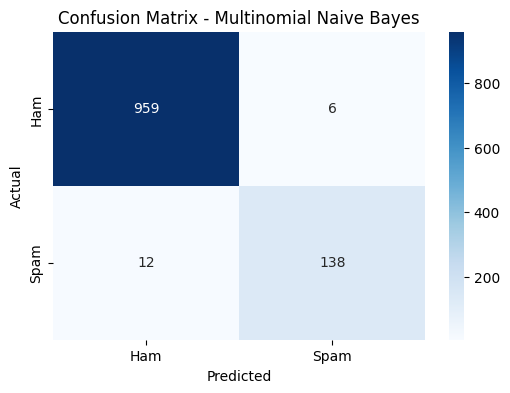

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/hp/Downloads/archive (8)/spam.csv', encoding='latin-1')  # Replace with your CSV path
df = df[['v1', 'v2']]  # Keep only relevant columns
df.columns = ['label', 'message']  # Rename columns for clarity

# Preprocess Data
df['label'] = df['label'].map({'ham': 0, 'spam': 1})  # Convert labels to binary (0: ham, 1: spam)
X = df['message']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(stop_words='english') # Convert Text to Features (Word Counts)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)

y_pred = mnb.predict(X_test_vec)
print("Predicated:",y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

Accuracy: 1.0


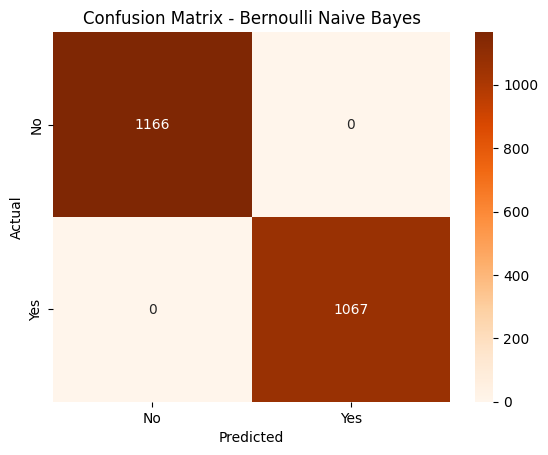

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/hp/Downloads/archive (10)/bank.csv')  # Replace with your CSV path
df['y'] = df['deposit'].map({'yes':1, 'no':0})  # Convert target to binary
y = df['deposit']

X = df.select_dtypes(include=['object']) # Use only categorical columns for simplicity
encoder = OneHotEncoder(sparse_output=False) # One-hot encode categorical features #returns a dense array instead of a sparse matrix.
X_encoded = pd.DataFrame(encoder.fit_transform(X), columns=encoder.get_feature_names_out())

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bernoulli Naive Bayes')
plt.show()

GaussianNB Accuracy: 0.734375
BernoulliNB Accuracy: 0.725
BernoulliNB Accuracy: 0.634375


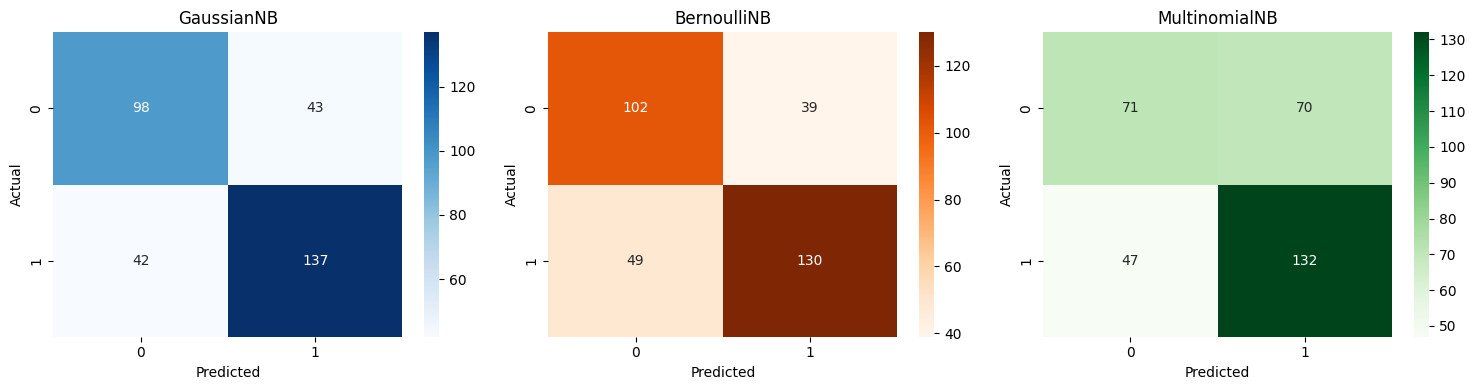

In [24]:
# TASK 9
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/hp/Downloads/archive (11)/winequality-red.csv')

# Create binary target
df['high_quality'] = (df['quality'] >= 6).astype(int)
y = df['high_quality']
X = df.drop(['quality', 'high_quality'], axis=1)

#  GaussianNB 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

#  BernoulliNB 
X_binary = (X > X.median()).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_binary, y, test_size=0.2, random_state=42)
bnb = BernoulliNB()
bnb.fit(X_train_b, y_train_b)
y_pred_bnb = bnb.predict(X_test_b)
print("BernoulliNB Accuracy:", accuracy_score(y_test_b, y_pred_bnb))
cm_bnb = confusion_matrix(y_test_b, y_pred_bnb)

# MultinomialNB 
X_count = X.round().astype(int)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_count, y, test_size=0.2, random_state=42)
mnb = MultinomialNB()
mnb.fit(X_train_m, y_train_m)
y_pred_mnb = mnb.predict(X_test_m)
print("BernoulliNB Accuracy:", accuracy_score(y_test_b, y_pred_mnb))
cm_mnb = confusion_matrix(y_test_m, y_pred_mnb)

# Plot Heatmaps 
plt.figure(figsize=(15,4))

# GaussianNB
plt.subplot(1,3,1)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title('GaussianNB')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# BernoulliNB
plt.subplot(1,3,2)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1], yticklabels=[0,1])
plt.title('BernoulliNB')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# MultinomialNB
plt.subplot(1,3,3)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.title('MultinomialNB')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


In [25]:
# KNN


=== Euclidean Distance ===
Accuracy: 1.0


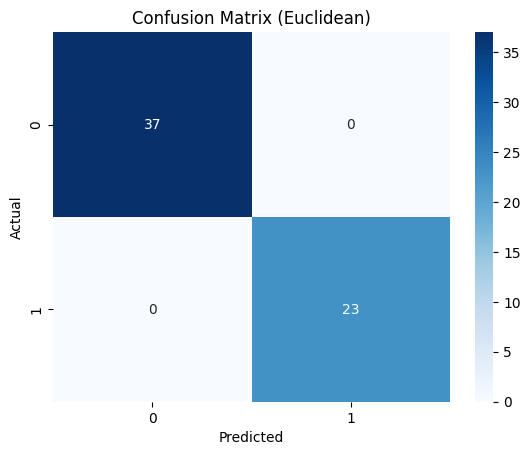

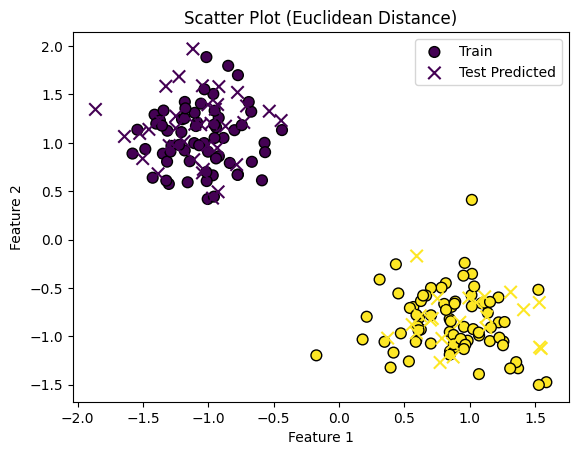


=== Manhattan Distance ===
Accuracy: 1.0


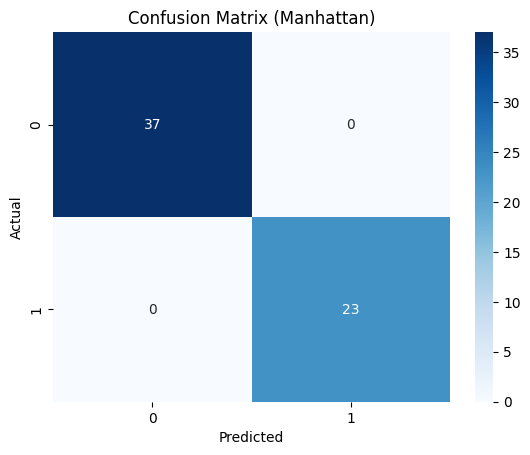

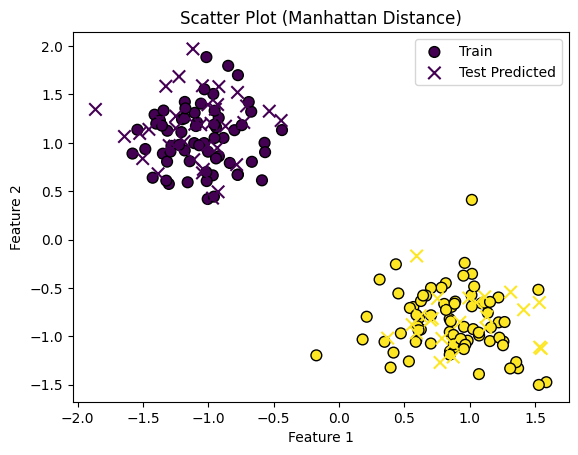


=== Minkowski (p=3) Distance ===
Accuracy: 1.0


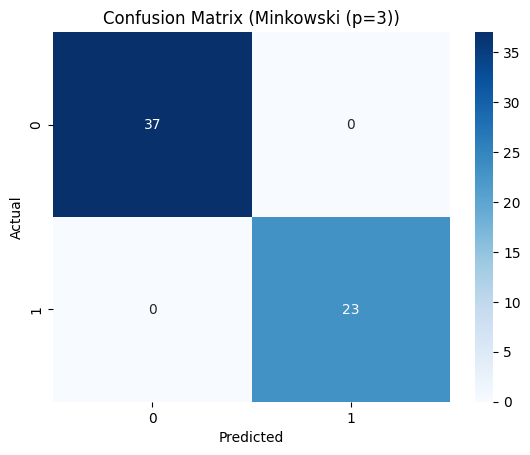

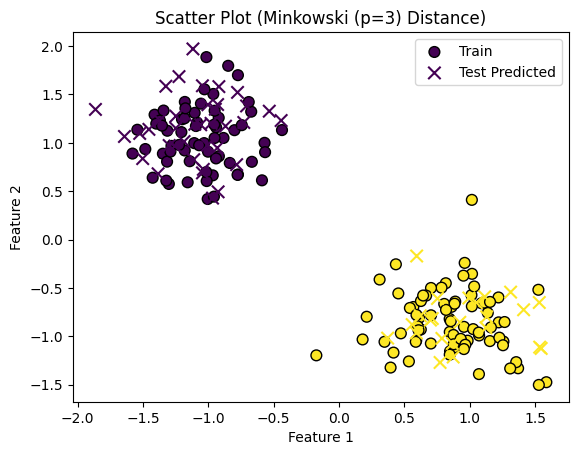

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

X, y = make_blobs(n_samples=200, centers=2, n_features=2,cluster_std=1.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

metrics = {
    'Euclidean': ('minkowski', 2),
    'Manhattan': ('minkowski', 1),
    'Minkowski (p=3)': ('minkowski', 3)
}

for name, (metric, p) in metrics.items():
    print(f"\n=== {name} Distance ===")
    
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric, p=p)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
  
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, label='Train', edgecolor='k', s=60)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, marker='x', s=80, label='Test Predicted')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Scatter Plot ({name} Distance)")
    plt.legend()
    plt.show()


=== Euclidean Distance ===
Best k: 14
Test Accuracy: 0.9555555555555556


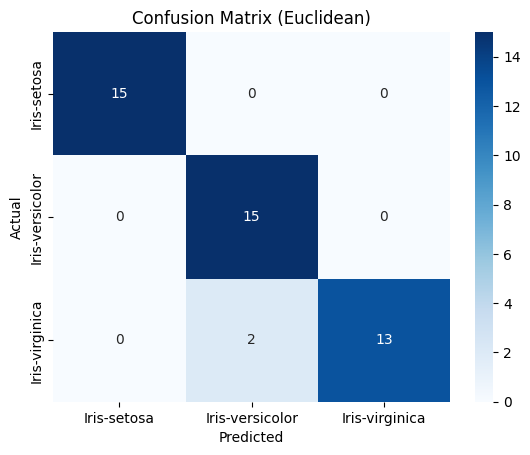

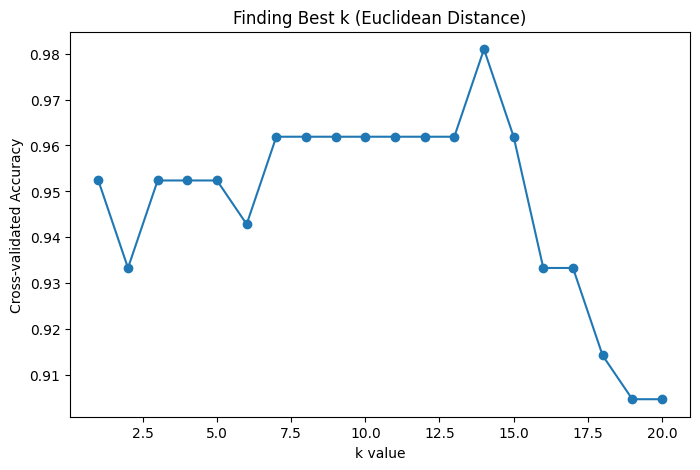


=== Manhattan Distance ===
Best k: 5
Test Accuracy: 0.9111111111111111


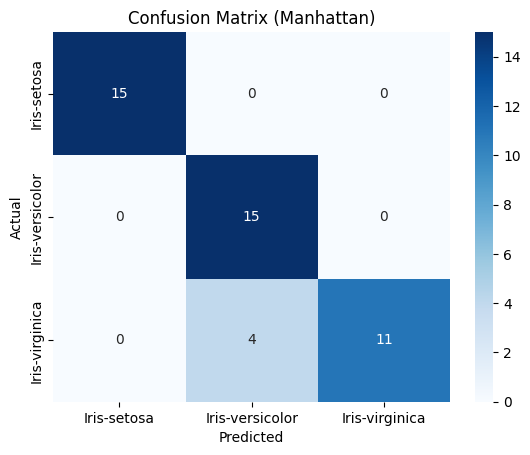

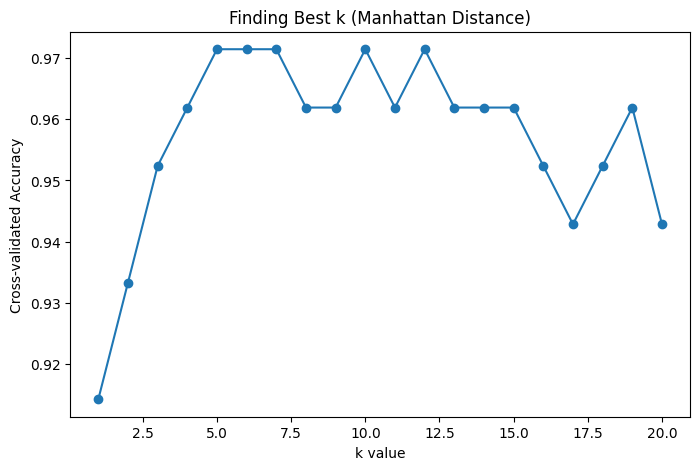


=== Minkowski (p=3) Distance ===
Best k: 14
Test Accuracy: 0.9333333333333333


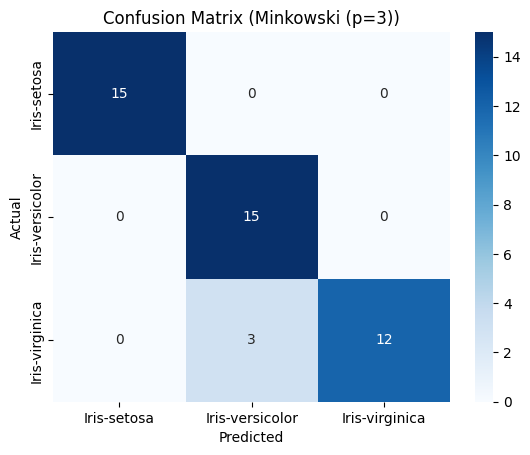

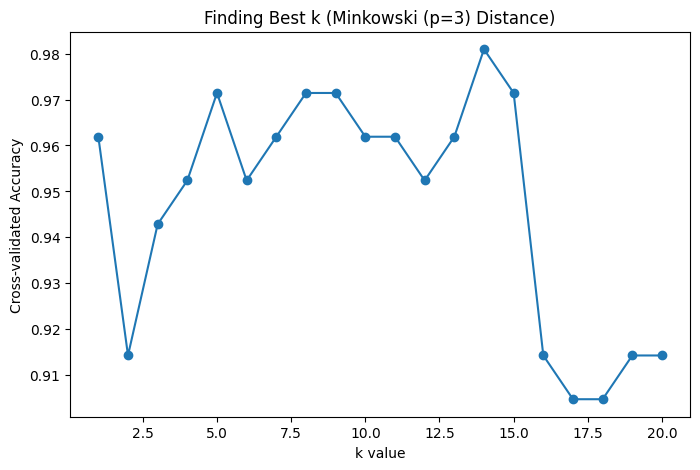

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
columns = ['sepal_length','sepal_width','petal_length','petal_width','class']
df = pd.read_csv(url, names=columns)

X = df.drop('class', axis=1).values
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

metrics = {
    'Euclidean': ('minkowski', 2), # power sqaure
    'Manhattan': ('minkowski', 1),
    'Minkowski (p=3)': ('minkowski', 3)
}

for name, (metric, p) in metrics.items():
    print(f"\n=== {name} Distance ===")
    
    k_values = range(1, 21)  # Find best k with cross-validation
    cv_scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=5)
        cv_scores.append(scores.mean())
    
    best_k = k_values[np.argmax(cv_scores)]
    print("Best k:", best_k)
    
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=p) # Train KNN with best k 
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test) # Predict test set
    acc = accuracy_score(y_test, y_pred)
    print("Test Accuracy:", acc)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({name})")
    plt.show()
    
    plt.figure(figsize=(8,5))     #  Accuracy vs k plot
    plt.plot(k_values, cv_scores, marker='o')
    plt.xlabel("k value")
    plt.ylabel("Cross-validated Accuracy")
    plt.title(f"Finding Best k ({name} Distance)")
    plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_11104\1672942787.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)



=== Euclidean Distance ===
Best k: 20
Test Accuracy: 0.774


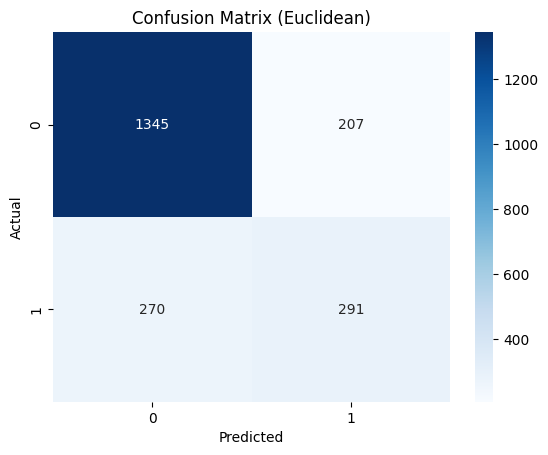

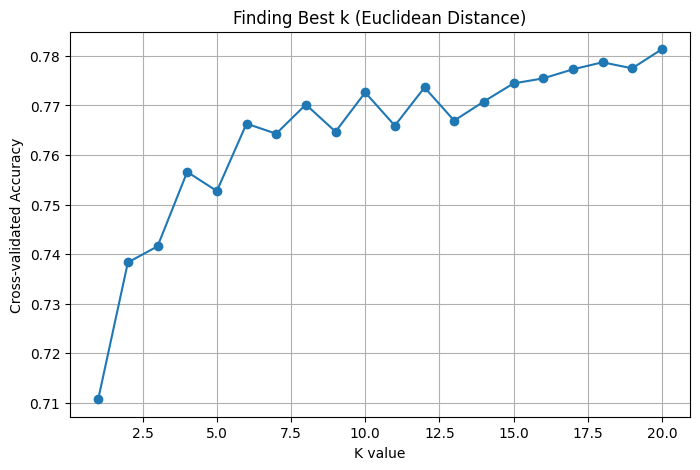


=== Manhattan Distance ===
Best k: 20
Test Accuracy: 0.788


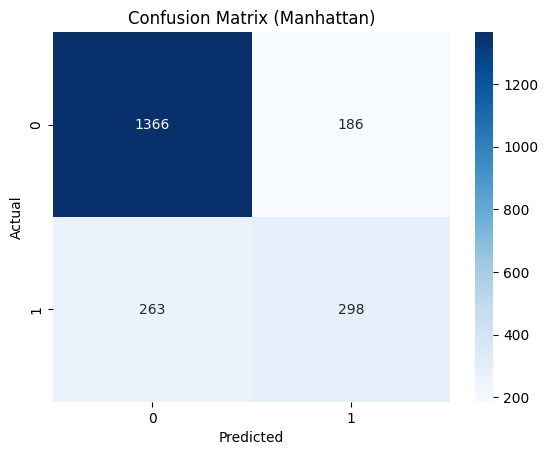

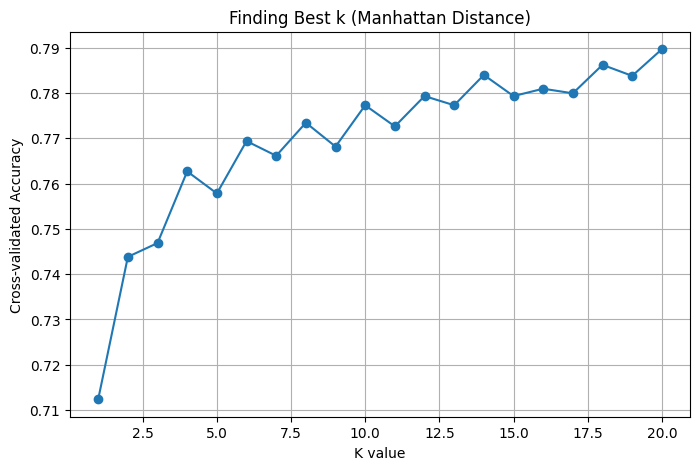


=== Minkowski (p=3) Distance ===
Best k: 20
Test Accuracy: 0.77


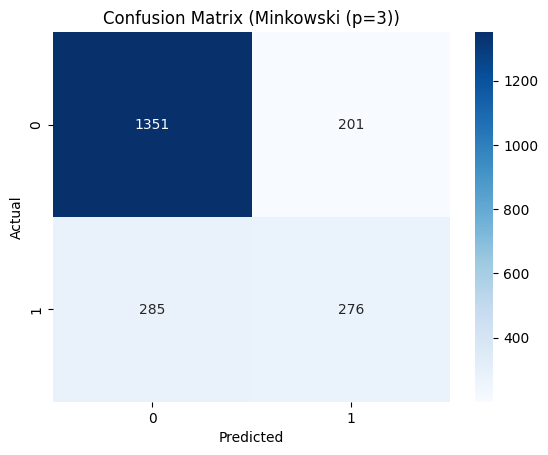

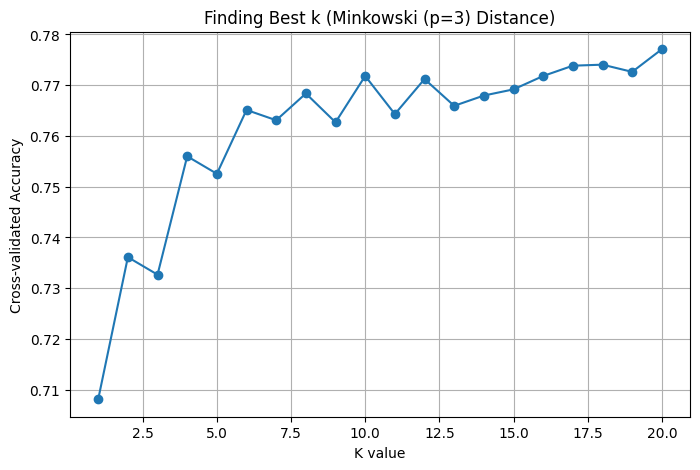

In [28]:
# TASK 10
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

le = LabelEncoder() # Label encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1).values
y = df['Churn'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

metrics = {
    'Euclidean': ('minkowski', 2),
    'Manhattan': ('minkowski', 1),
    'Minkowski (p=3)': ('minkowski', 3)
}

# Run KNN for all metrics
for name, (metric, p) in metrics.items():
    print(f"\n=== {name} Distance ===")
    
    k_values = range(1, 21)
    cv_scores = []
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=5)
        cv_scores.append(scores.mean())
    
    best_k = k_values[np.argmax(cv_scores)]
    print("Best k:", best_k)

    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=p)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Test Accuracy:", round(acc, 3))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({name})")
    plt.show()
    
    plt.figure(figsize=(8,5))  # Accuracy vs K Plot
    plt.plot(k_values, cv_scores, marker='o')
    plt.xlabel("K value")
    plt.ylabel("Cross-validated Accuracy")
    plt.title(f"Finding Best k ({name} Distance)")
    plt.grid(True)
    plt.show()

In [29]:
# DECISION TREE

Accuracy (Gini): 0.3333333333333333
Accuracy (Entropy): 1.0


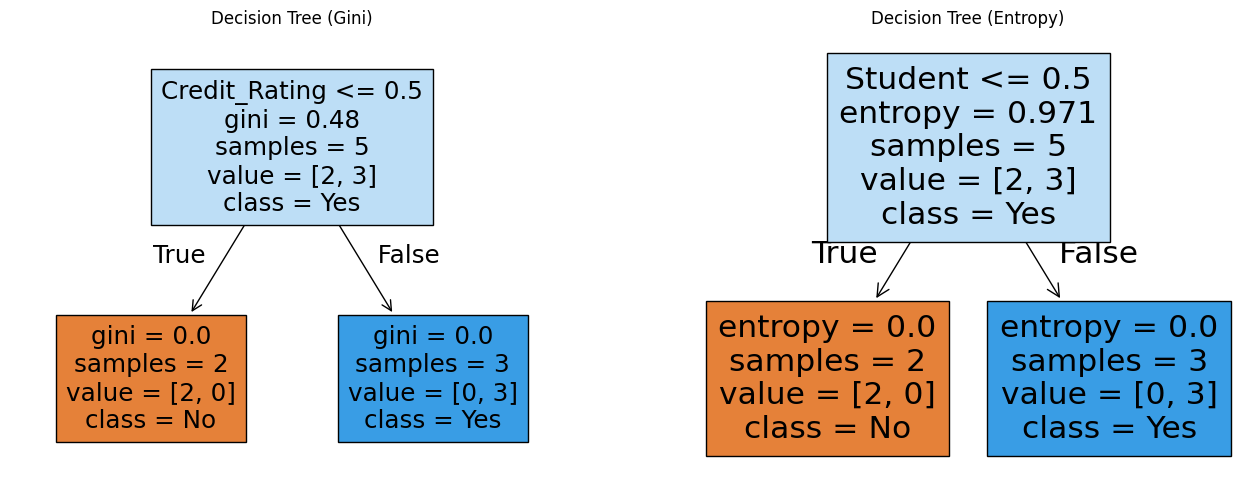

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = {
    'Age': [25, 30, 28, 40, 35, 22, 38, 28],
    'Income': [50000, 60000, 52000, 80000, 72000, 48000, 75000, 54000],
    'Student': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Excellent', 'Fair', 'Excellent', 'Fair', 'Excellent'],
    'Buys_Computer': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']
}
df = pd.DataFrame(data)

le_student = LabelEncoder()
le_credit = LabelEncoder()

df['Student'] = le_student.fit_transform(df['Student'])
df['Credit_Rating'] = le_credit.fit_transform(df['Credit_Rating'])
y = df['Buys_Computer']
X = df.drop('Buys_Computer', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3) # Train Decision Tree using Gini
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)
print("Accuracy (Gini):", acc_gini)

clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3) # Train Decision Tree using Entropy
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)
print("Accuracy (Entropy):", acc_entropy)

plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)# Gini Tree
plot_tree(clf_gini, feature_names=X.columns, class_names=clf_gini.classes_, filled=True)
plt.title("Decision Tree (Gini)")
plt.subplot(1, 2, 2) # Entropy Tree
plot_tree(clf_entropy, feature_names=X.columns, class_names=clf_entropy.classes_, filled=True)
plt.title("Decision Tree (Entropy)")
plt.show()

GINI Decision Tree
Accuracy: 0.7132867132867133
Confusion Matrix:
 [[67 20]
 [21 35]]

 ENTROPY Decision Tree
Accuracy: 0.7062937062937062
Confusion Matrix:
 [[66 21]
 [21 35]]


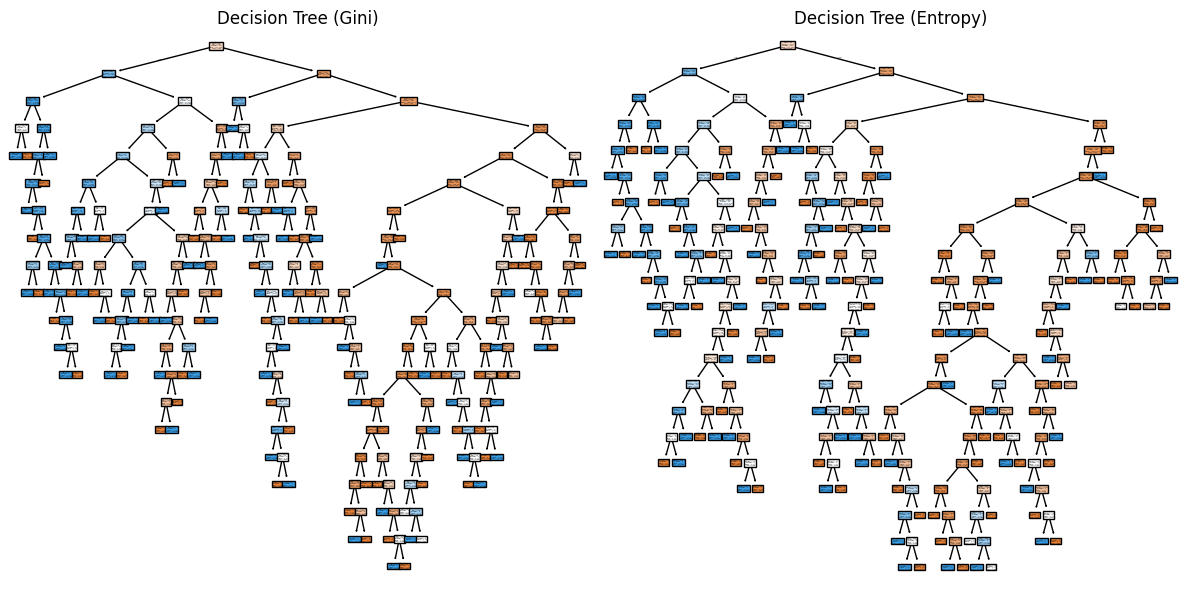

In [31]:
# Titanic Survival Prediction using Decision Tree (Gini vs Entropy)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']]  # select useful columns
df.dropna(inplace=True)                                # remove missing values

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # male=1, female=0

X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_gini = DecisionTreeClassifier(criterion='gini', random_state=0) # Using Gini Index
clf_gini.fit(X_train, y_train)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0) # Using Entropy
clf_entropy.fit(X_train, y_train)

y_pred_gini = clf_gini.predict(X_test)
y_pred_entropy = clf_entropy.predict(X_test)
print("GINI Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("\n ENTROPY Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plot_tree(clf_gini, feature_names=X.columns, class_names=['Died','Survived'], filled=True)
plt.title("Decision Tree (Gini)")
plt.subplot(1,2,2)
plot_tree(clf_entropy, feature_names=X.columns, class_names=['Died','Survived'], filled=True)
plt.title("Decision Tree (Entropy)")
plt.tight_layout()
plt.show()

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

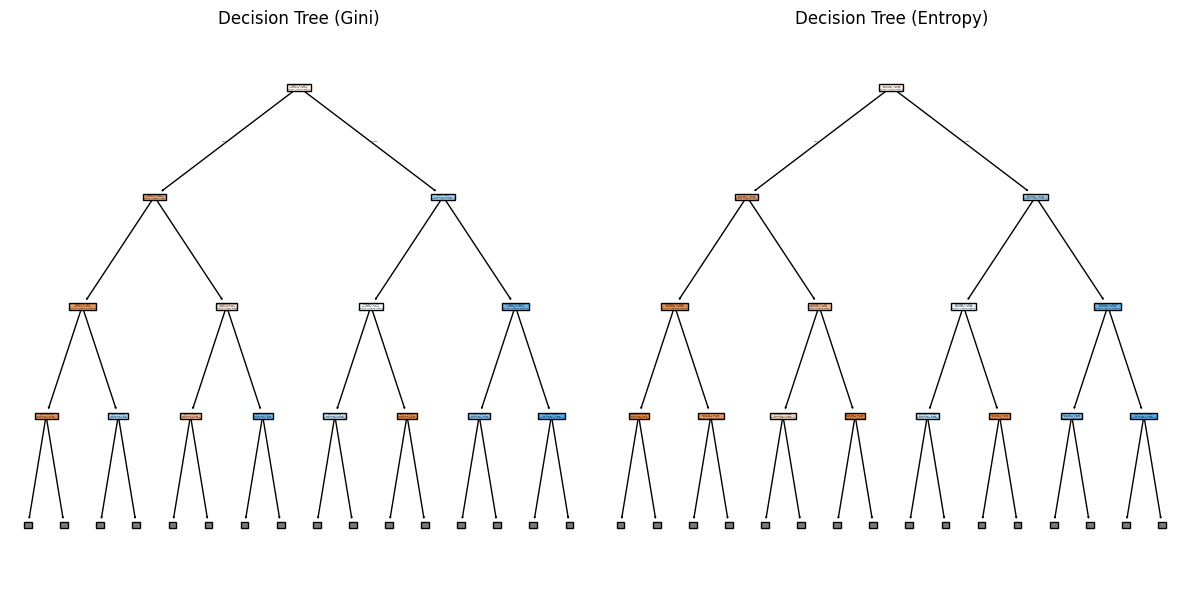

In [32]:
# TASK 11

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

url = "C:/Users/hp/Downloads/archive (12)/bank.csv"
df = pd.read_csv(url)
print(df.head())
print(df.info())

df.dropna(inplace=True)

label = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col])

X = df.drop('deposit', axis=1)
y = df['deposit']  # target column: 1 means subscribed, 0 means not subscribed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_gini = DecisionTreeClassifier(criterion='gini', random_state=0)
clf_gini.fit(X_train, y_train)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf_entropy.fit(X_train, y_train)

y_pred_gini = clf_gini.predict(X_test)
y_pred_entropy = clf_entropy.predict(X_test)
print("🔹 GINI Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("\n🔸 ENTROPY Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plot_tree(clf_gini, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree (Gini)")
plt.subplot(1,2,2)
plot_tree(clf_entropy, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree (Entropy)")
plt.tight_layout()
plt.show()